#  YOLO 

<!-- [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1d--jyNUIyCfu7kqCzS_axSZTuJZFUID8#scrollTo=EFAO3VOrllIY) -->


Modern models for industrial applications `You Look Only Once` (`YOLO`) represent single-stage optimized approaches to solving [a set of common computer vision tasks](https://docs.ultralytics.com/tasks/).

The YOLO architecture allows you to solve the following tasks:
* [Detection of individual objects](https://docs.ultralytics.com/tasks/detect/)(`object detection`).
* [Segmentation of objects](https://docs.ultralytics.com/tasks/segment/)(`instance segmentation`).
* [Key Point Detection](https://docs.ultralytics.com/tasks/pose/)(`key point detection`/`pose Estimation`).
* [Object detection and orientation](https://docs.ultralytics.com/tasks/obb/)(`oriented object detection`/`oriented bounding boxes`).
* [Object tracking in video sequences](https://docs.ultralytics.com/modes/track/)(`object tracking`/`Multi-object tracking`).
* [Classification of images (objects in images)](https://docs.ultralytics.com/tasks/classify/)(`image classification`).

An illustration of the tasks solved using YOLO

<img width="900" src="https://yolov8.org/wp-content/uploads/2024/01/How-Does-YOLOv8-Work-2-1024x536.webp">


<blockquote>

Most of the `YOLO` models are supported by [`Ultralitics` companies](https://www.ultralytics.com/) and [`Roboflow`](https://roboflow.com/) and is in the [public domain](https://github.com/ultralytics ). The advantages of this approach are the simplicity of research work with YOLO models, and their implementation in final software products.

Today, among the `YOLO` architectures, it is necessary to distinguish such as:
* [`YOLO 8`](https://docs.ultralytics.com/models/yolov8/) is a modern multitasking architecture without anarchic object detection.
* [`YOLO 11`](https://docs.ultralytics.com/models/yolov10/) - One of the latest modified models of `YOLO`.
* [`YOLO 12`](https://docs.ultralytics.com/models/yolov10/) is one of the latest refinements of the `YOLO` approach.

A full list of current YOLO models supported by Ultralitics can be found in the [official documentation](https://docs.ultralytics.com/models/).
  
* In fact, each YOLO model is a family of models for [solving relevant tasks](https://docs.ultralytics.com/models/yolo12/#supported-tasks-and-modes). The basic model solves the problem of object detection. For example, the model with the `-cls` suffix is designed to solve classification problems.
* Also, almost every YOLO model [available in several versions of different sizes](https://docs.ultralytics.com/models/yolo12/#detection-performance-coco-val2017). As a rule, the `nano` model is the smallest (e.g. `YOLO12n`), and the `x` model (e.g. `YOLO12x`) is the largest.
* Note that the YOLO architecture does not include a solution to such a popular problem as semantic segmentation. This task must be solved separately. For example, using the library [<code>smp</code>](https://smp.readthedocs.io/en/latest/)
* In addition to those indicated today, [a number of more specific tasks] can also be solved (https://docs.ultralytics.com/solutions/#solutions ), however, based on those already described above. Also [here](https://github.com/ultralytics/ultralytics/tree/main/examples) you can find a number of official examples of working with `YOLO` models.
* It is important to note that each type of task will require its own [data annotation format (their разметки)](https://docs.ultralytics.com/guides/data-collection-and-annotation/#types-of-data-annotation).
* Also note that not all single-stage models are represented by Ultralitics. This is how you can find, for example, [`yolos` models](https://huggingface.co/docs/transformers/en/model_doc/yolos) within the framework of the eco-system `huggingface`. You can also view a number of models on the [`paperwithcode` website](https://paperswithcode.com/task/real-time-object-detection).
* Architectures have two interfaces: [`CLI`](https://docs.ultralytics.com/usage/cli/) - comand line interface and [`Python API`](https://docs.ultralytics.com/usage/python/) is a library for `Python`. We will use the second method.

# Import

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import ssl
ssl._create_default_https_context = ssl._create_stdlib_context

In [2]:
# %pip install -U ultralytics

In [3]:
try:
    import ultralytics
except:
    %pip install ultralytics
    import ultralytics
    ultralytics.checks()

In [4]:
import ultralytics

In [5]:
import os
import cv2
import glob
import yaml
import urllib
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
from shutil import copyfile
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Rectangle
from torchvision.datasets.utils import download_and_extract_archive

Before you start working with ultralytics, you should also configure it. This includes disabling logging, which will not be needed in this lesson.
The settings can be obtained as a dictionary [`settings`](https://docs.ultralytics.com/quickstart/#ultralytics-settings ). All settings [see the official documentation](https://docs.ultralytics.com/usage/cfg/).

> Note that, in general, logging is an extremely important tool and it is recommended in real experiments. Ultralytics provides several logging options to choose from.

In [6]:
from ultralytics import settings
settings.update({"wandb": False, "tensorboard": False, "clearml":False, "mlflow":False, "neptune":False, 'comet': False, 'dvc': False, 'hub': False, 'raytune':False })

In [7]:
from ultralytics import YOLO

# Testing YOLO

## Transfer learning `YOLO`

The main family of YOLO models has weight parameters that are trained on a dataset of __Common Objects in Context__ ([`COCO`](https://cocodataset.org/)). [Such a set](https://www.kaggle.com/code/shazminnasir/object-detection-using-yolov8-on-coco-dataset#5.-Listing-Classes-in-COCO-Dataset ) of the parameters is called the model - __neural network pre-training__.

<blockquote>

<b>Pre-training is necessary as a means of initializing and regularizing a neural network before training it on target data.</b>

The pre-training process is as follows:
* The neural network is first trained on a large, repeatedly validated data set, learning the general patterns and features of working with images.
* When solving target tasks, this basic knowledge will be used as a foundation.
* On the target data set, the neural network __learns__ - no longer learning the general patterns of the data, but only adapting them to the target task.

<details><summary> Details</summary> 

As a rule, __pre-training allows__:
* learn the neural network faster (to retrain)
* require less data to train on the target dataset  
* give more accurate results (regularization effect)

Note that there are different strategies for using pre-trained models. The strategy used in this example is called advanced training (__fine tuning__).  In the previous lesson, the transfer learning strategy was shown as additional materials. In this case, only the head part of the neural network was completed. In general, we can say that the more data or the more complex the task, the more complex the strategy should be chosen.

__In other words.__
The effect of pre-learning is to first teach the neural network to recognize common features of images (edges, corners, shapes, colors), or even common silhouettes, such as the silhouette of a car. With further training, the neural network can use this knowledge to recognize specific car brands.

</details>

## `YOLO`  tasks

[Let's launch variants of YOLO v8 nano models](https://docs.ultralytics.com/models/yolov8/) To solve a set of tasks:
* `yolov8n.pt ` - object detection
* `yolov8n-seg.pt ` - instance segmentation
* `yolov8n-obb.pt ` - detection of oriented objects
* `yolov8n-pose.pt ` - key point detection
* `yolov8n-cls.pt ` - classification task

<blockquote>
Let's celebrate! The task of searching and detecting objects in images is the main task of YOLO models, so the model will load without suffixes.

In [9]:
model = YOLO("yolov8n.pt")
results = model.predict("https://ultralytics.com/images/zidane.jpg",imgsz=640)
results[0].save(filename="result-od.jpg")

model = YOLO("yolov8n-seg.pt")
results = model.predict("https://ultralytics.com/images/zidane.jpg",imgsz=640)
results[0].save(filename="result-seg.jpg")

model = YOLO("yolov8n-pose.pt")
results = model.predict("https://ultralytics.com/images/zidane.jpg",imgsz=640)
results[0].save(filename="result-pose.jpg")

model = YOLO("yolov8n-obb.pt")
results = model.predict("https://ultralytics.com/images/zidane.jpg",imgsz=640)
results[0].save(filename="result-obb.jpg")

model = YOLO("yolov8n-cls.pt")
results = model.predict("https://ultralytics.com/images/zidane.jpg",imgsz=640)
results[0].save(filename="result-cls.jpg")


Found https://ultralytics.com/images/zidane.jpg locally at zidane.jpg
image 1/1 /Users/mvronkin/Documents/DLCVCourseEn/WS/zidane.jpg: 384x640 2 persons, 1 tie, 64.5ms
Speed: 2.1ms preprocess, 64.5ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

Found https://ultralytics.com/images/zidane.jpg locally at zidane.jpg
image 1/1 /Users/mvronkin/Documents/DLCVCourseEn/WS/zidane.jpg: 384x640 2 persons, 1 tie, 77.8ms
Speed: 2.3ms preprocess, 77.8ms inference, 2.7ms postprocess per image at shape (1, 3, 384, 640)

Found https://ultralytics.com/images/zidane.jpg locally at zidane.jpg
image 1/1 /Users/mvronkin/Documents/DLCVCourseEn/WS/zidane.jpg: 384x640 2 persons, 58.2ms
Speed: 2.1ms preprocess, 58.2ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

Found https://ultralytics.com/images/zidane.jpg locally at zidane.jpg
image 1/1 /Users/mvronkin/Documents/DLCVCourseEn/WS/zidane.jpg: 384x640 56.7ms
Speed: 1.8ms preprocess, 56.7ms inference, 1.2ms postprocess p

'result-cls.jpg'

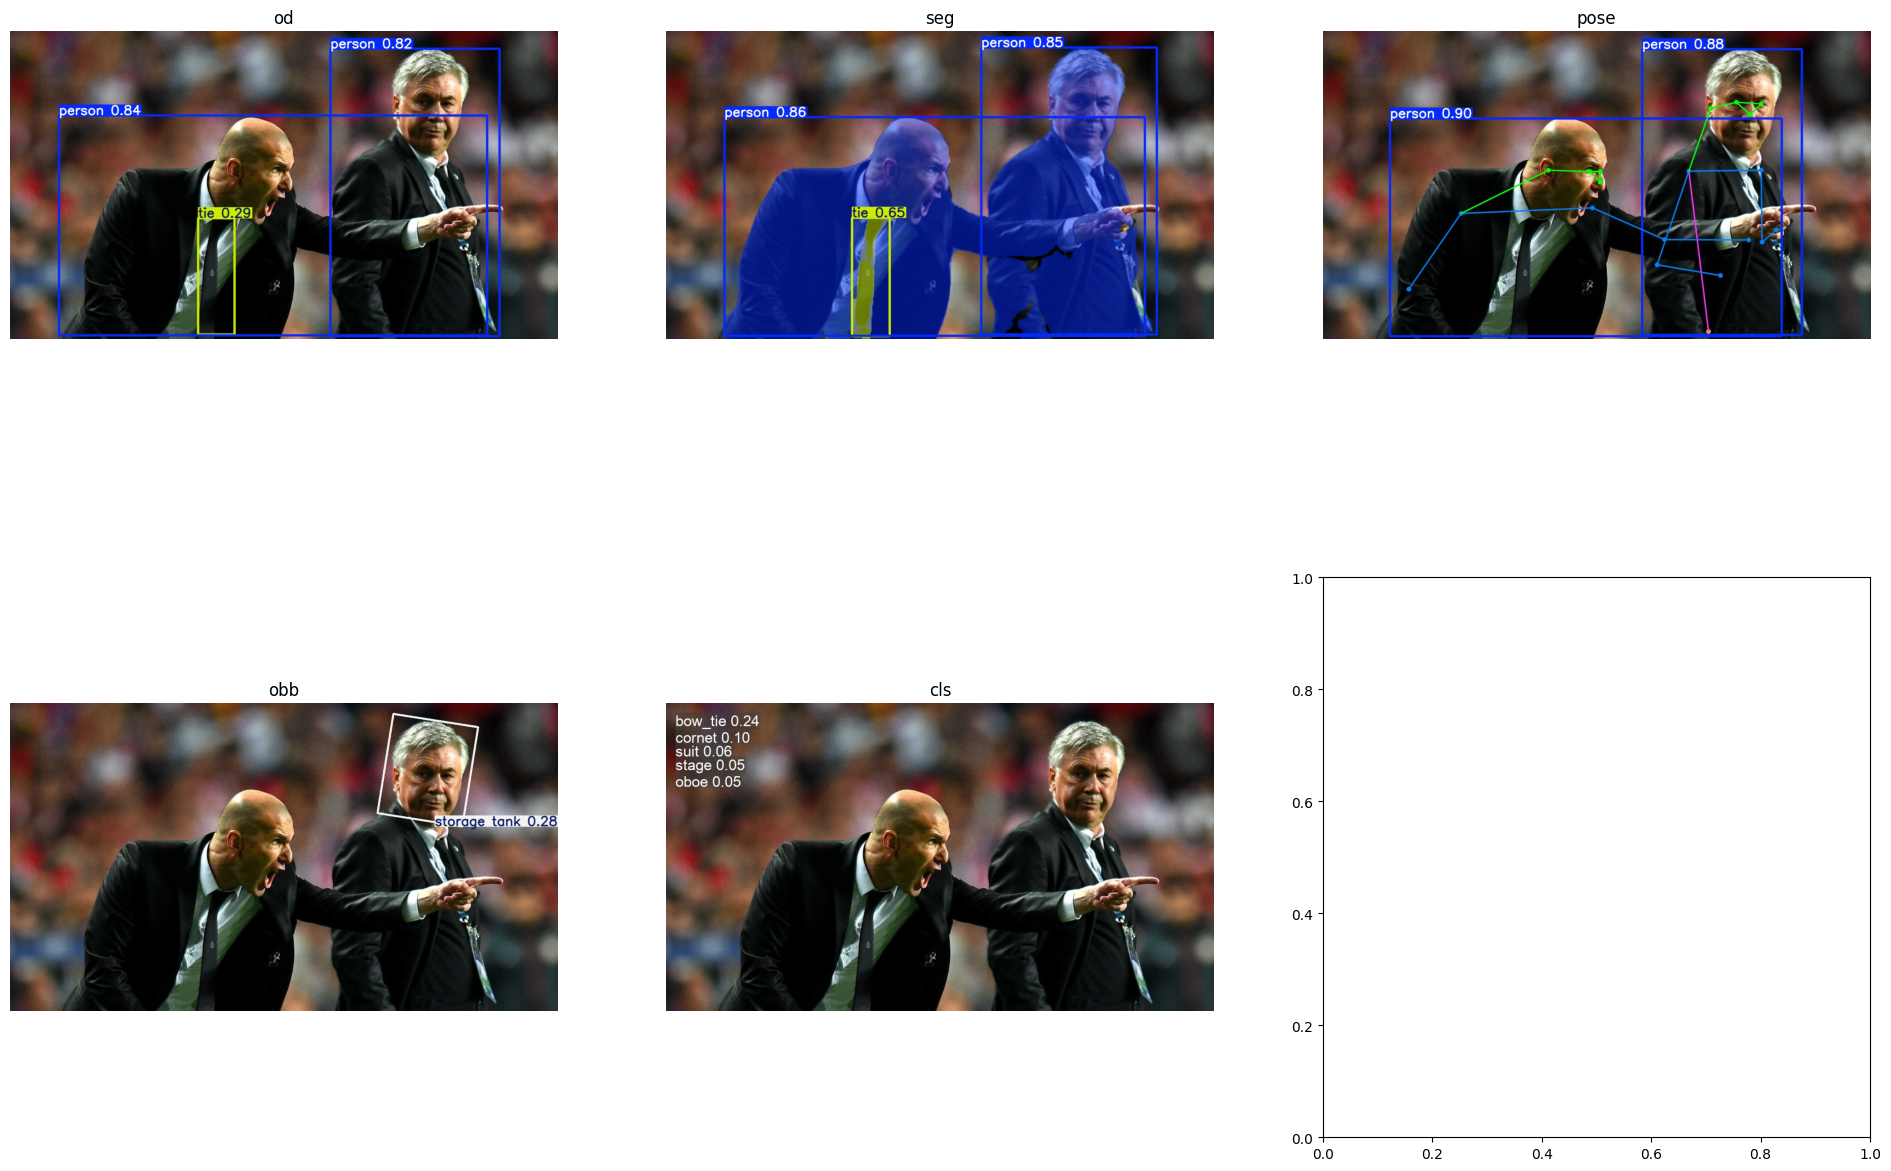

In [10]:
tasks = ['od','seg','pose','obb','cls']
fig, axs = plt.subplots(2,len(tasks)//2+1, figsize=(24,16))

for ax, task in zip(axs.ravel(),tasks):
    ax.imshow(cv2.imread('result-'+task+'.jpg')[:,:,::-1]); ax.set_axis_off(); ax.set_title(task);
plt.show()

# dataset `YOLO`

Before training the model, let's download the dataset. This dataset is a simplified version of the ["helmet detection dataset"](https://www.kaggle.com/datasets/andrewmvd/hard-hat-detection/). A simplified version of the kit presents the task of detecting 2 classes of objects: helmets and their absence at industrial facilities. That is, the purpose of solving the problem is [automation of safety control at industrial facilities](https://github.com/wujixiu/helmet-detection). Examples of images are given below:

|<img src="https://github.com/wujixiu/helmet-detection/raw/master/hardhat-wearing-detection/imgs/00877.jpg" width="200 pixels">|<img src="https://github.com/wujixiu/helmet-detection/raw/master/hardhat-wearing-detection/imgs/00197.jpg " width="200 pixels">|<img src="https://github.com/wujixiu/helmet-detection/raw/master/hardhat-wearing-detection/imgs/00807.jpg" width="200 pixels">|

>Please note that I have prepared this question in the tutorial to study the YOU model. The original set requires conversion.
>
>An original review in [Wu, J., Cai, N., Chen, W., Wang, H., & Wang, G. (2019). Automatic detection of protective helmets worn by construction personnel: an approach to deep learning and a set of control data. Automation in construction, 106, 102894.](https://www.sciencedirect.com/science/article/pii/S092658051930264X?casa_token=lZOoxDD_MfcAAAAA:EhPy_5DULKJLuRh5SdQmA-mvbxfC2mxKpB4IOJog_7P66cn6O7fMjOiB1jV1k-Ufq2QZ_7jKmg).

let's download dataset

In [11]:
url = "https://github.com/MVRonkin/Deep-Learning-Foundation-Course/raw/refs/heads/main/DLUtilits/Helmet.zip"

archive_name = url.split('/')[-1]
root_directory = os.path.join(os.getcwd(),'datasets')
dataset_directory = os.path.splitext(os.path.join(root_directory,archive_name))[0]

if not os.path.exists(dataset_directory):
    download_and_extract_archive(url, root_directory)

print(os.listdir(dataset_directory))

100%|███████████████████████████████████████| 30.7M/30.7M [01:01<00:00, 501kB/s]


['.DS_Store', 'images', 'labels', 'data.yaml']


dataset structure

```bash
dataset/
├── images/
│   ├── test/
│   └── valid/
│   └── train/
├── labels/
    ├── test/
    └── valid/
    └── train/
```

Where the `images` directory contains the images themselves, whereas the `labels` directory contains the markup for the images.

The directory also contains the attached __dataset description file data.yaml__. The path to this file will need to be specified as an option when training the model. This file will describe the class names (`names`), their number (`nc`), as well as the paths to the training, validation, and test datasets.

<details><summary> for more information, see the markup format <code>YOLO</code>.</summary>
<blockquote>    

The `YOLO` format assumes that each image has a markup file in the format `*.txt`.
 The markup file must contain lines in the format
 
```
{class} {xc} {yc} {w} {h}
{class} {xc} {yc} {w} {h}
...
```

where <br>
`xc` and `yc` are the coordinates of the center of each object; <br>
`w` and `h` are the width and height of each object. 
All values must be set in relative units. The absolute values are normalized to the width and height of the image.

</blockquote>
</details>

Before starting the training of the __model, we will rewrite the file with the description of the dataset__ `*.yaml`. In the file, we set the paths to the images of the training, validation, and test parts. We will also set the total number of classes (`nc`) and their names to 0 and 1.

In [12]:
data = {
    f'train': str(Path(dataset_directory) / 'images' / 'train'),
    f'val': str(Path(dataset_directory) / 'images' / 'val'),
    f'test': str(Path(dataset_directory) / 'images' / 'test'),
    'nc': 2,
    'names': ['0','1']
}

data_yaml = Path(dataset_directory)  / 'data.yaml'
with open(data_yaml, 'w') as file:
    yaml.safe_dump(data, file)



In [13]:
with open(data_yaml, 'r') as file:
    data=yaml.safe_load( file)
print(data)

{'names': ['0', '1'], 'nc': 2, 'test': '/Users/mvronkin/Documents/DLCVCourseEn/WS/datasets/Helmet/images/test', 'train': '/Users/mvronkin/Documents/DLCVCourseEn/WS/datasets/Helmet/images/train', 'val': '/Users/mvronkin/Documents/DLCVCourseEn/WS/datasets/Helmet/images/val'}


visualize

In [14]:
def plot_yolo_annotation(img_folder, label_folder, img_id, class_names=None):

    img_name = os.listdir(img_folder)[img_id]
    # Загружаем изображение
    img_path = os.path.join(img_folder, f"{img_name}")

    image = Image.open(img_path)
    img_w, img_h = image.size
    fig, ax = plt.subplots(1,1,figsize = (4,4))

    # Загружаем аннотации
    label_path = os.path.join(label_folder, f"{img_name.split('.')[0]}.txt")
    with open(label_path, 'r') as f:
        annotations = f.readlines()
    ann_ = np.zeros((len(annotations), 5))
    for i,ann in enumerate(annotations):
        ann_[i,:] = list(map(float, ann.strip().split()) )
        class_id, x_center, y_center, width, height = ann_[i,:]
        edgecolor='red';
        if class_id ==0: edgecolor='green'
        # Конвертируем YOLO-формат в абсолютные координаты

        x_center *= img_w; y_center *= img_h
        width    *= img_w; height   *= img_h

        # Координаты левого верхнего угла
        x_min, y_min = x_center - width / 2, y_center - height / 2

        # Рисуем прямоугольник
        rect = Rectangle((x_min, y_min), width, height,
            linewidth=2, edgecolor=edgecolor, facecolor='none')
        ax.add_patch(rect)

        # Подпись класса (если заданы имена)
        if class_names:
            class_name = class_names[int(class_id)]
            ax.text(
                x_min, y_min - 5, class_name,
                color=edgecolor, fontsize=12, bbox=dict(facecolor='white', alpha=0.7)
            )
        else:
            ax.text(
                x_min, y_min - 5, f"Class {int(class_id)}",
                color=edgecolor, fontsize=12, bbox=dict(facecolor='white', alpha=0.7)
            )
    ax.imshow(image); ax.set_axis_off(); plt.show()
    return image,  ann_

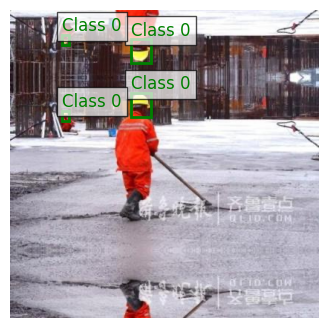

In [15]:
test_img_folder = Path(dataset_directory)  / 'images' /'test'
test_label_folder = Path(dataset_directory)  / 'labels' /'test'
class_names = ['helmet','head']  # Название класса (как в data.yaml)

# Показываем изображение с аннотациями
image,  annotations = plot_yolo_annotation(test_img_folder, test_label_folder, img_id=1);

# training `YOLO` 

After describing the dataset, we will train the model as shown below.

Note that the following training arguments can be set.

```
- epochs (int): The number of study periods.
- batch (int): The size of the training package.
- imgsz (int): The size of the input image.
- device (str): The device on which the training is performed (for example, 'cuda', 'cpu').
- workers (int): the number of worker threads to download the data.
- optimizer (str): An optimizer used for training.
- lr0 (floating value): The initial learning rate.
- patience (average value): The waiting time during which there will be no noticeable improvement in early termination of training.
```

and others.

In [26]:
model = YOLO("yolo12n.pt")
results = model.train(data=data_yaml,
                      imgsz=416, 
                      epochs=2, 
                      amp=False, 
                      batch = 16, 
                      lr0 = 0.001, 
                      workers = 0)

New https://pypi.org/project/ultralytics/8.4.51 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.122 🚀 Python-3.12.2 torch-2.9.1 CPU (Apple M1)
engine/trainer: task=detect, mode=train, model=yolo12n.pt, data=/Users/mvronkin/Documents/DLCVCourseEn/WS/datasets/Helmet/data.yaml, epochs=2, time=None, patience=100, batch=16, imgsz=416, save=True, save_period=-1, cache=False, device=None, workers=0, project=None, name=train3, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=False, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_fra

train: Scanning /Users/mvronkin/Documents/DLCVCourseEn/WS/datasets/Helmet/labels

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 163.5±59.6 MB/s, size: 59.7 KB)



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
val: Scanning /Users/mvronkin/Documents/DLCVCourseEn/WS/datasets/Helmet/labels/v

Plotting labels to /Users/mvronkin/Yandex.Disk.localized/ОК Анализ данных и ИИ/Авторские материалы/Практические задания/7. Обучение НС/runs/detect/train3/labels.jpg... 


...

        2/2         0G       1.67      2.044      1.189        138        416: 1
                 Class     Images  Instances      Box(P          R      mAP50  m

                   all         50        275     0.0165       0.88     0.0892     0.0442



2 epochs completed in 0.167 hours.
Optimizer stripped from /Users/mvronkin/Yandex.Disk.localized/ОК Анализ данных и ИИ/Авторские материалы/Практические задания/7. Обучение НС/runs/detect/train3/weights/last.pt, 5.5MB
Optimizer stripped from /Users/mvronkin/Yandex.Disk.localized/ОК Анализ данных и ИИ/Авторские материалы/Практические задания/7. Обучение НС/runs/detect/train3/weights/best.pt, 5.5MB

Validating /Users/mvronkin/Yandex.Disk.localized/ОК Анализ данных и ИИ/Авторские материалы/Практические задания/7. Обучение НС/runs/detect/train3/weights/best.pt...
Ultralytics 8.3.122 🚀 Python-3.12.2 torch-2.9.1 CPU (Apple M1)
YOLOv12n summary (fused): 159 layers, 2,557,118 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  m


                   all         50        275     0.0138      0.695      0.101     0.0502
                     0         47        211     0.0227      0.858      0.197     0.0986
                     1         10         64    0.00483      0.531    0.00401    0.00187
Speed: 2.9ms preprocess, 303.6ms inference, 0.0ms loss, 8.4ms postprocess per image
Results saved to /Users/mvronkin/Yandex.Disk.localized/ОК Анализ данных и ИИ/Авторские материалы/Практические задания/7. Обучение НС/runs/detect/train3


Among the validation results, the most important [are metrics](https://docs.ultralytics.com/guides/yolo-performance-metrics/#object-detection-metrics ) `mAP50` and `mAP50-95'.
The mAP (mean Average Precision) metric is the average accuracy for all classes and objects whose outline borders intersect with the markup with an area larger than the specified threshold. The threshold is measured in IoU - the intersection area divided by the total area of the objects.
Values:
* $mAP50$ — accuracy at a fixed $IoU=50\%$ (standard threshold).
* $mAP50:95$ — average accuracy for a more rigorous assessment (from $50\%$ to $95\%$ $IoU$).
The higher the values, the better the model detects objects with different localization accuracy.
    
<!-- Note that this algorithm corresponds to the method described, for example, [тут](https://github.com/aladdinpersson/Machine-Learning-Collection/blob/master/ML/Pytorch/object_detection/metrics/mean_avg_precision.py) . -->

In [28]:
print(f"mAP@0.5: {100*results.box.map:.2f}%")  # Основная метрика

mAP@0.5: 5.02%


save results `save_best_path` in  `best_weights_pth`.

<details><summary>Details</summary>

In fact, all logging results are stored in the `runs` directory. For example, the learning outcomes for the object detection task have approximately the following structure:
    
```
    .
└── detect
   └── train
       ├── args.yaml
       ├── labels.jpg
       ├── labels_correlogram.jpg
       ├── results.csv
       ├── train_batch0.jpg
       ├── train_batch1.jpg
       ├── train_batch2.jpg
       ├── val_batch0_labels.jpg
       ├── val_batch0_pred.jpg
       ├── val_batch1_labels.jpg
       ├── val_batch1_pred.jpg
       └── weights
           ├── best.pt
           └── last.pt
```    
</details>

In [29]:
def save_best_path(results, fname = 'best.pt'):
    current_best_weights_pth = os.path.join(str(results.save_dir),'weights','best.pt')
    best_weights_pth = os.path.join(os.getcwd(),fname)
    copyfile(current_best_weights_pth, best_weights_pth)
    return best_weights_pth
best_weights_pth = save_best_path(results, fname = 'best.pt')

In [30]:
model = YOLO(best_weights_pth)
results = model.train(data=data_yaml,imgsz=416, epochs=3, amp=False, batch = 8, lr0 = 0.001, workers = 0)

New https://pypi.org/project/ultralytics/8.4.51 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.122 🚀 Python-3.12.2 torch-2.9.1 CPU (Apple M1)
engine/trainer: task=detect, mode=train, model=/Users/mvronkin/Documents/DLCVCourseEn/WS/best.pt, data=/Users/mvronkin/Documents/DLCVCourseEn/WS/datasets/Helmet/data.yaml, epochs=3, time=None, patience=100, batch=8, imgsz=416, save=True, save_period=-1, cache=False, device=None, workers=0, project=None, name=train4, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=False, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=F

train: Scanning /Users/mvronkin/Documents/DLCVCourseEn/WS/datasets/Helmet/labels

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 189.3±86.4 MB/s, size: 59.7 KB)



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
val: Scanning /Users/mvronkin/Documents/DLCVCourseEn/WS/datasets/Helmet/labels/v

Plotting labels to /Users/mvronkin/Yandex.Disk.localized/ОК Анализ данных и ИИ/Авторские материалы/Практические задания/7. Обучение НС/runs/detect/train4/labels.jpg... 


...

                   all         50        275      0.709      0.538      0.661      0.343

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size



        3/3         0G       1.55       1.39       1.19         38        416: 1
                 Class     Images  Instances      Box(P          R      mAP50  m


                   all         50        275       0.68      0.607      0.693      0.396

3 epochs completed in 0.089 hours.
Optimizer stripped from /Users/mvronkin/Yandex.Disk.localized/ОК Анализ данных и ИИ/Авторские материалы/Практические задания/7. Обучение НС/runs/detect/train4/weights/last.pt, 5.5MB
Optimizer stripped from /Users/mvronkin/Yandex.Disk.localized/ОК Анализ данных и ИИ/Авторские материалы/Практические задания/7. Обучение НС/runs/detect/train4/weights/best.pt, 5.5MB

Validating /Users/mvronkin/Yandex.Disk.localized/ОК Анализ данных и ИИ/Авторские материалы/Практические задания/7. Обучение НС/runs/detect/train4/weights/best.pt...
Ultralytics 8.3.122 🚀 Python-3.12.2 torch-2.9.1 CPU (Apple M1)
YOLOv12n summary (fused): 159 layers, 2,557,118 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  m


                   all         50        275      0.658      0.614      0.692      0.396
                     0         47        211      0.706       0.74      0.796       0.46
                     1         10         64       0.61      0.489      0.587      0.333
Speed: 0.7ms preprocess, 141.7ms inference, 0.0ms loss, 4.4ms postprocess per image
Results saved to /Users/mvronkin/Yandex.Disk.localized/ОК Анализ данных и ИИ/Авторские материалы/Практические задания/7. Обучение НС/runs/detect/train4


In [31]:
best_weights_pth = save_best_path(results, fname = 'best.pt')

In [32]:
print(f"mAP@0.5: {100*results.box.map:.2f}%")  # Основная метрика

mAP@0.5: 39.62%


# test

In [24]:
os.listdir(results.save_dir)
Image.open(os.path.join(str(results.save_dir),'val_batch1_pred.jpg'))

AttributeError: 'list' object has no attribute 'save_dir'

In [25]:
model = YOLO(best_weights_pth)
results = model.val()  # Автоматически использует данные из data.yaml


NameError: name 'best_weights_pth' is not defined

 `map`.

In [39]:
print(f"mAP@0.5: {100*results.box.map:.2f}%")  # Основная метрика

mAP@0.5: 45.99%


## Testing the model

In order to use the model in working mode (as well as in the test sample), it is enough to call the `predict` method for the specified paths to images ('img_path')

```python
  # Example of working with 5 images from the test dataset
img_paths = [img_path for img_path, _ in zip(test_img_folder.iterdir(), range(5))]
results = model.predict(img_paths)
``


Let's see what the results of the model for 3 images look like.


image 1/1 C:\Users\Ronkin\Documents\GitHub\Deep-Learning-in-Image-Processing-Lectures\2025\WS\datasets\Helmet\images\test\hard_hat_workers1168.jpg: 416x416 3 0s, 12.6ms
Speed: 0.7ms preprocess, 12.6ms inference, 1.8ms postprocess per image at shape (1, 3, 416, 416)

image 1/1 C:\Users\Ronkin\Documents\GitHub\Deep-Learning-in-Image-Processing-Lectures\2025\WS\datasets\Helmet\images\test\hard_hat_workers118.jpg: 416x416 4 0s, 4 1s, 12.0ms
Speed: 1.5ms preprocess, 12.0ms inference, 2.9ms postprocess per image at shape (1, 3, 416, 416)

image 1/1 C:\Users\Ronkin\Documents\GitHub\Deep-Learning-in-Image-Processing-Lectures\2025\WS\datasets\Helmet\images\test\hard_hat_workers122.jpg: 416x416 7 0s, 4 1s, 13.4ms
Speed: 1.0ms preprocess, 13.4ms inference, 2.7ms postprocess per image at shape (1, 3, 416, 416)


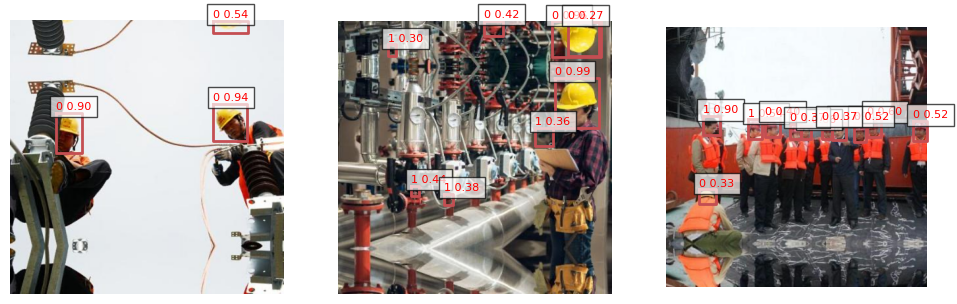

In [40]:
fig,axs = plt.subplots(1,3, figsize=(12, 4))
#1. Получаем список тестовых изображений
for img_path, ax in zip(test_img_folder.iterdir(), axs):

    # 2. Предсказание и отображение
    results = model.predict(img_path, save=False)  # Не сохранять на диск

    # Визуализация через matplotlib
    img = Image.open(img_path)
    ax.imshow(img)

    for box in results[0].boxes:
        # Координаты bounding box
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        ax.plot([x1, x2, x2, x1, x1], [y1, y1, y2, y2, y1], 'r-', linewidth=2)

        # Подпись класса
        cls = int(box.cls)
        conf = float(box.conf)
        label = f"{model.names[cls]} {conf:.2f}"
        ax.text(x1, y1 - 5, label, color='red', fontsize=8,
                bbox=dict(facecolor='white', alpha=0.7))
    ax.set_axis_off()
plt.show()

Now let's evaluate the accuracy on the test sample. To do this, we also use the validation function, but specify the parameter `split='test".

In [41]:
results = model.val(data=data_yaml, split='test' )

Ultralytics 8.3.127  Python-3.12.7 torch-2.7.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 8187MiB)
val: Fast image access  (ping: 0.10.0 ms, read: 16.46.1 MB/s, size: 66.9 KB)


val: Scanning C:\Users\Ronkin\Documents\GitHub\Deep-Learning-in-Image-Processing-Lectures\2025\WS\datasets\Helmet\label

val: New cache created: C:\Users\Ronkin\Documents\GitHub\Deep-Learning-in-Image-Processing-Lectures\2025\WS\datasets\Helmet\labels\test.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:02<0


                   all         50        282      0.777      0.755      0.851      0.524
                     0         45        245      0.927      0.619      0.792      0.445
                     1          8         37      0.628      0.892       0.91      0.604
Speed: 0.8ms preprocess, 5.8ms inference, 0.0ms loss, 3.2ms postprocess per image
Results saved to runs\detect\val2


In [43]:
print(f"mAP@0.5: {100*results.box.map:.2f}")

mAP@0.5: 52.44


## Submission

In [44]:
def round_(x, digits=2):
    return (x*100//1)/100
#-------------------------------------------------------------
def yolo_results(model, img_folder, n_imgs=2):
    if n_imgs is None:
        n_imgs = len(list(Path(img_folder).iterdir()))
    n_imgs = min(n_imgs, len(list(Path(img_folder).iterdir())))     
        
    img_paths = [x for x,_ in zip(Path(img_folder).iterdir(), range(n_imgs)) if str(x).endswith(('jpg','png'))]

    if not img_paths:
        print("Не найдены изображения в указанной директории.")
        return
    results = model.predict(img_paths, save=False) 
    return results
#-------------------------------------------------------------
def yolo_predicts(img_folder, results, n_imgs=None):

    if n_imgs is None:
        n_imgs = len(list(Path(img_folder).iterdir()))
    n_imgs = min(n_imgs, len(results), len(list(Path(img_folder).iterdir())))          
        
    img_paths = [x for x,_ in zip(Path(img_folder).iterdir(), range(n_imgs)) if str(x).endswith(('jpg','png'))]

    outputs = []
    if not img_paths:
        print("Не найдены изображения в указанной директории.")
        return outputs
    
    for img_path, result in zip(img_paths, results):
        # Создаем базовую структуру предсказаний
        output = yolo_predict_struct(img_path, result)
        outputs.append(output)
  
    return outputs
#---------------------------------------------------------
def yolo_predict_struct(img_path, result):

    img = Image.open(img_path)
    w, h = img.size
    
    output = {
        'name': img_path.stem,
        'size': [w, h],
        'predict': []
    }
    
    for box in result.boxes:
        # Координаты bounding box
        x1, y1, x2, y2 = box.xyxy[0].tolist()

        cls = int(box.cls)
        conf = round_(float(box.conf))

        output['predict'].append([cls, conf, round_(x1), round_(y1), round_(x2), round_(y2)])
    
    return output

In [48]:
submit_img_folder = Path(dataset_directory) / 'images' / 'test'
results = yolo_results(model, submit_img_folder, n_imgs=None)   
outs = yolo_predicts(submit_img_folder, results)


0: 416x416 3 0s, 3.0ms
1: 416x416 4 0s, 4 1s, 3.0ms
2: 416x416 7 0s, 4 1s, 3.0ms
3: 416x416 5 0s, 3.0ms
4: 416x416 2 0s, 3.0ms
5: 416x416 5 0s, 3.0ms
6: 416x416 3 0s, 3.0ms
7: 416x416 5 0s, 3.0ms
8: 416x416 3 0s, 1 1, 3.0ms
9: 416x416 2 0s, 3.0ms
10: 416x416 4 0s, 3 1s, 3.0ms
11: 416x416 3 0s, 2 1s, 3.0ms
12: 416x416 7 0s, 1 1, 3.0ms
13: 416x416 3 0s, 3.0ms
14: 416x416 5 0s, 3.0ms
15: 416x416 2 0s, 3.0ms
16: 416x416 6 0s, 3.0ms
17: 416x416 2 0s, 3.0ms
18: 416x416 6 1s, 3.0ms
19: 416x416 13 0s, 1 1, 3.0ms
20: 416x416 7 0s, 2 1s, 3.0ms
21: 416x416 4 0s, 3.0ms
22: 416x416 1 0, 3.0ms
23: 416x416 9 0s, 3.0ms
24: 416x416 2 0s, 3.0ms
25: 416x416 14 0s, 3.0ms
26: 416x416 6 0s, 3.0ms
27: 416x416 1 0, 1 1, 3.0ms
28: 416x416 5 0s, 3.0ms
29: 416x416 1 0, 10 1s, 3.0ms
30: 416x416 3 0s, 1 1, 3.0ms
31: 416x416 13 0s, 3.0ms
32: 416x416 1 0, 3.0ms
33: 416x416 4 0s, 3.0ms
34: 416x416 3 0s, 11 1s, 3.0ms
35: 416x416 4 0s, 3.0ms
36: 416x416 4 0s, 3.0ms
37: 416x416 3 0s, 3.0ms
38: 416x416 4 0s, 3.0ms
39: 4

In [49]:
import json

name_ = 'ФИО'
filename = f'submit {name_}.json'

with open(filename, 'w') as f:
    json.dump(outs, f, indent=4)